# Project Deliverable 2: Regression Modeling and Performance Evaluation

## Dataset
Student Performance Dataset (`student-por.csv`)

## Goal
The goal of this deliverable is to build regression models to predict the final grade (`G3`) and compare model performance.

## Data Preparation

Before modeling, I checked the dataset structure and converted the numeric columns to the correct data type.

I also handled both numeric and categorical features by using a preprocessing pipeline.
This pipeline includes imputation, scaling, and one-hot encoding.

This step helped prepare the data in a consistent way before training the regression models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [ ]:
# Load the dataset
df = pd.read_csv("data/student-por.csv", sep=";")
print("Shape:", df.shape)
df.head()

Shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


### Dataset and Target

I used the `student-por.csv` dataset again.

The target variable is `G3`, which is the final grade.

This dataset is a good fit for regression because it includes many student-related features that may help predict final performance.

This new feature may capture overall past performance in a simpler way.

In [ ]:
# Feature engineering

# Create a simple engineered feature from earlier grades
df["avg_grade"] = (pd.to_numeric(df["G1"]) + pd.to_numeric(df["G2"])) / 2

# Make sure numeric columns are numeric
numeric_cols = [
    "age", "Medu", "Fedu", "traveltime", "studytime", "failures",
    "famrel", "freetime", "goout", "Dalc", "Walc", "health",
    "absences", "G1", "G2", "G3", "avg_grade"
]

# Convert selected columns to numeric type
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

### Feature Engineering

I created one new feature called `avg_grade`.

This feature is the average of `G1` and `G2`.

I added it because early grades may help predict the final grade better than using each one separately.

In [ ]:
# Separate input features and target variable
X = df.drop(columns=["G3"])
y = df["G3"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (649, 33)
y shape: (649,)


In [ ]:
# Split features into numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'avg_grade']
Categorical features: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


/var/folders/qg/m9_9gxgs7vsd772504rkj6kc0000gn/T/ipykernel_14432/1263164068.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [ ]:
# Preprocessing for numeric features
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numeric and categorical preprocessing
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (519, 33)
Test shape: (130, 33)


In [ ]:
# Build the Linear Regression pipeline
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])


# Build the Ridge Regression pipeline
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

In [ ]:
# Train both regression models
linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [ ]:
# Evaluate each model with common regression metrics
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    return pd.DataFrame({
        "Model": [model_name],
        "R2": [r2],
        "MSE": [mse],
        "RMSE": [rmse]
    })

results_test = pd.concat([
    evaluate_model(linear_model, X_test, y_test, "Linear Regression"),
    evaluate_model(ridge_model, X_test, y_test, "Ridge Regression")
], ignore_index=True)

results_test

,Model,R2,MSE,RMSE
0,Linear Regression,0.848651,1.475909,1.214870
1,Ridge Regression,0.848736,1.475086,1.214531


In [ ]:
# Use 5-fold cross-validation to measure model stability
cv_linear = cross_val_score(
    linear_model, X, y, cv=5, scoring="r2"
)

cv_ridge = cross_val_score(
    ridge_model, X, y, cv=5, scoring="r2"
)

cv_results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "CV Mean R2": [cv_linear.mean(), cv_ridge.mean()],
    "CV Std R2": [cv_linear.std(), cv_ridge.std()]
})

cv_results

,Model,CV Mean R2,CV Std R2
0,Linear Regression,0.793911,0.042593
1,Ridge Regression,0.794420,0.042912


### Model Evaluation

I evaluated both models using:
- R-squared
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)

I also used 5-fold cross-validation to check how well the models generalize to unseen data.

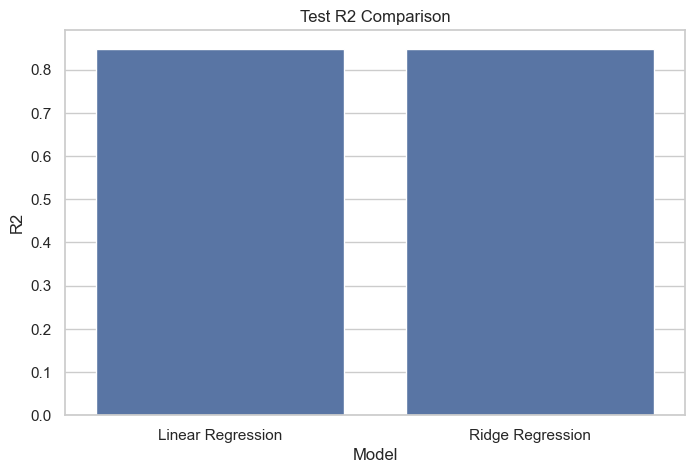

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_test, x="Model", y="R2")
plt.title("Test R2 Comparison")
plt.show()

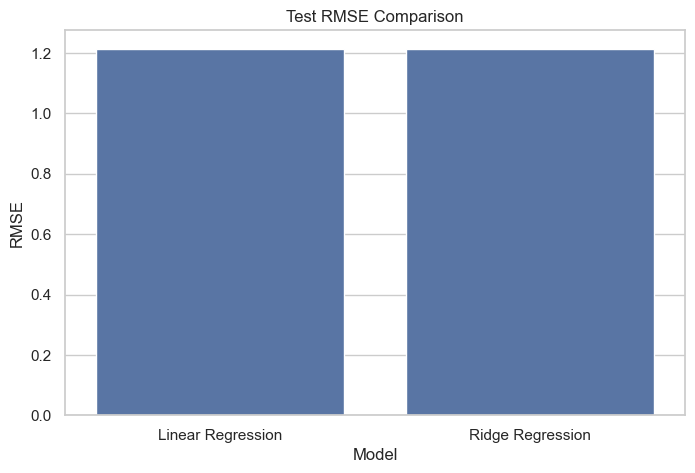

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_test, x="Model", y="RMSE")
plt.title("Test RMSE Comparison")
plt.show()

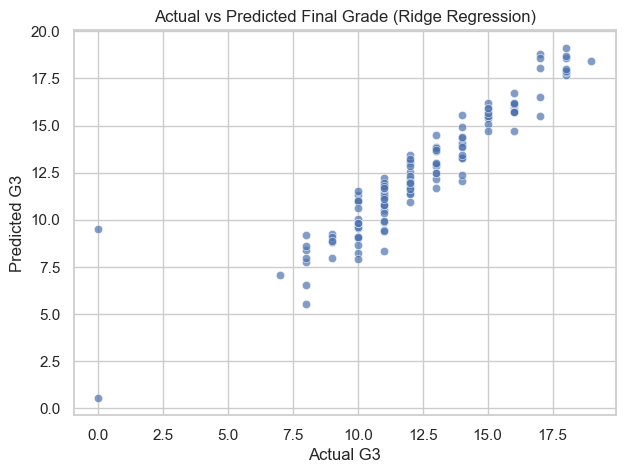

In [ ]:
# Plot actual vs predicted values for the Ridge model
ridge_pred = ridge_model.predict(X_test)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=ridge_pred, alpha=0.7)
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted Final Grade (Ridge Regression)")
plt.show()

### Plot Interpretation

The points follow a clear upward trend, which shows that the predictions are closely aligned with the actual final grades.

A few low-grade cases show larger error, but overall the model fits the data well.

## Results Summary

I compared Linear Regression and Ridge Regression.

Both models performed very well and gave very similar results.

On the test set, Ridge Regression performed slightly better than Linear Regression:
- Linear Regression: R² = 0.848651, MSE = 1.475909, RMSE = 1.214870
- Ridge Regression: R² = 0.848736, MSE = 1.475086, RMSE = 1.214531

I also used 5-fold cross-validation to measure generalization:
- Linear Regression: mean R² = 0.793911
- Ridge Regression: mean R² = 0.794420

These results show that Ridge Regression was the best model, although the difference was very small. Overall, both models predicted final grade well.

The cross-validation scores were also very close, which suggests that both models were stable across different folds.

## Conclusion

In this deliverable 2, I built two regression models to predict the final grade (`G3`) using the student performance dataset.

I performed feature engineering by creating `avg_grade`, which is the average of `G1` and `G2`.

I also used both numeric and categorical features through preprocessing and one-hot encoding. The two models were Linear Regression and Ridge Regression. Both models showed strong performance, but Ridge Regression performed slightly better on both the test set and cross-validation results.

The final results suggest that student final grade can be predicted reasonably well from earlier grades and other student-related factors. Based on the evaluation results, I selected Ridge Regression as the best model because it had the highest test R², the lowest RMSE, and the highest mean cross-validation R², even though the difference was small.